In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/colina/dsipms_15mm/")
filenames = sorted(path.glob("*.h5"))
filename  = filenames[0]
len(filenames)

10

In [4]:
testdf = imgs_from_file(filename)
testdf

,x0,y0,z0,r0,image
event,,,,,
0,28.427392,13.095063,-5.177589,31.298519,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0,..."
1,22.400540,-5.778143,-5.199509,23.133766,"[[[0, 0, 1, 1, 0, 1, 0, 0, 0, 0], [1, 0, 0, 3,..."
2,-7.550546,-9.699058,-5.183395,12.291561,"[[[2, 3, 0, 0, 1, 0, 0, 1, 0, 0], [4, 2, 3, 2,..."
3,-14.203231,21.167087,-5.199817,25.490731,"[[[0, 0, 0, 2, 2, 3, 5, 1, 6, 5], [0, 0, 1, 3,..."
4,-23.575234,-15.714317,-5.196890,28.332515,"[[[3, 5, 4, 6, 4, 4, 2, 1, 0, 0], [9, 6, 9, 6,..."
...,...,...,...,...,...
29995,-16.406641,-21.339546,-5.171360,26.917543,"[[[3, 4, 1, 3, 0, 1, 1, 3, 0, 0], [5, 4, 8, 6,..."
29996,-1.876207,-9.240139,-5.194952,9.428697,"[[[1, 1, 1, 2, 3, 3, 2, 1, 0, 0], [2, 1, 5, 4,..."
29997,-9.638247,18.494376,-5.197443,20.855161,"[[[0, 0, 0, 2, 2, 0, 1, 4, 1, 4], [0, 2, 3, 1,..."


In [5]:
config    = simconfig(filename)
sipm_pos  = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[0]
sipm_x    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[1]
sipm_y    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[2]
extents   = sipm_extent   (config.sipm_size, config.sipm_gap, config.n_sipm_side)
ticks     = np.arange(-15, 16, 10) if config.el_diam==32 else np.arange(-30, 31, 15)

rmax   = config.el_diam/2
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)

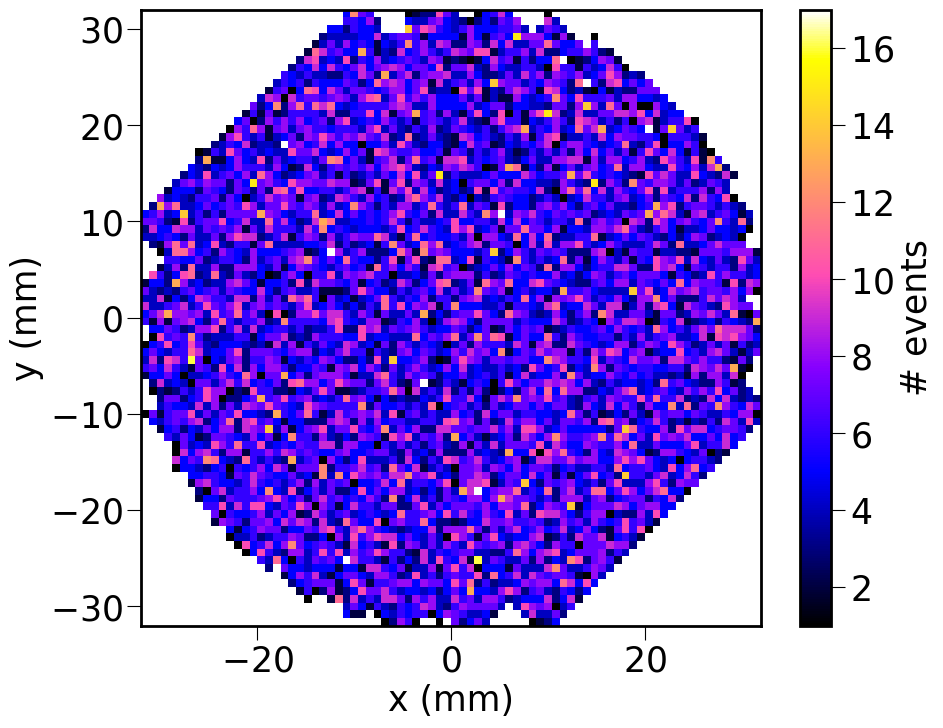

In [6]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

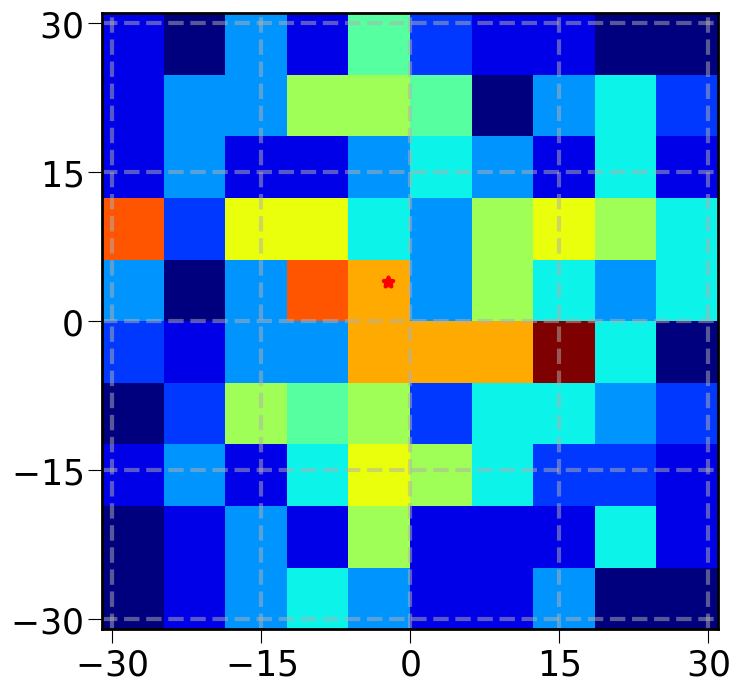

In [7]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

# Barycenter

In [8]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [9]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,12.733846,6.406667,28.427392,13.095063,-5.177589,31.298519,-15.693546,-6.688397,17.059368
1,10.223922,-2.516471,22.400540,-5.778143,-5.199509,23.133766,-12.176618,3.261673,12.605893
2,-0.106897,-7.963793,-7.550546,-9.699058,-5.183395,12.291561,7.443649,1.735265,7.643236
3,-7.390179,10.351786,-14.203231,21.167087,-5.199817,25.490731,6.813053,-10.815301,12.782348
4,-12.187255,-4.801961,-23.575234,-15.714317,-5.196890,28.332515,11.387979,10.912356,15.772304
...,...,...,...,...,...,...,...,...,...
29995,-9.332461,-8.878010,-16.406641,-21.339546,-5.171360,26.917543,7.074180,12.461536,14.329477
29996,-0.590970,-6.003010,-1.876207,-9.240139,-5.194952,9.428697,1.285237,3.237129,3.482935
29997,-3.334848,7.303788,-9.638247,18.494376,-5.197443,20.855161,6.303399,-11.190588,12.843757


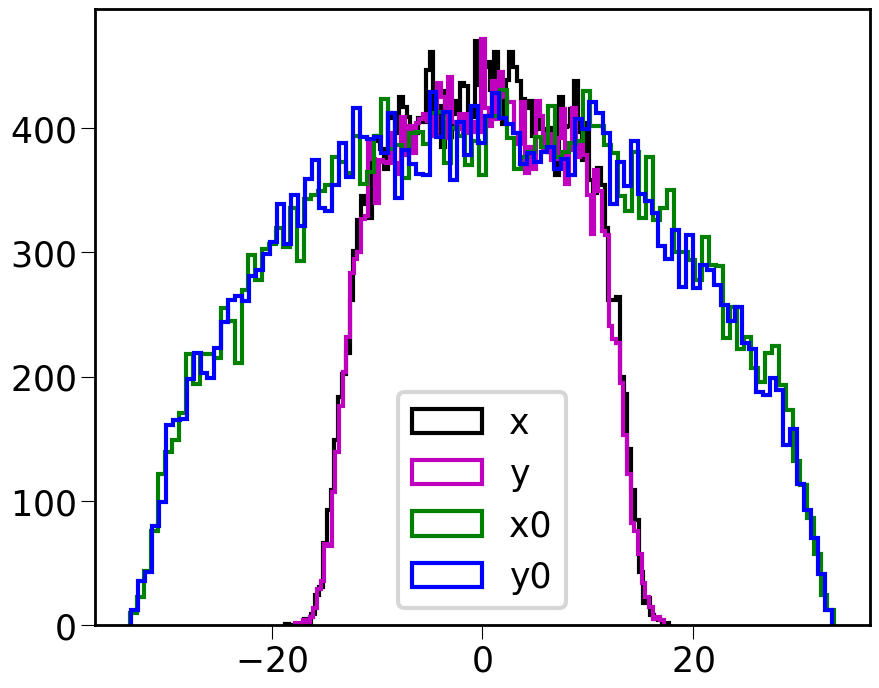

In [10]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

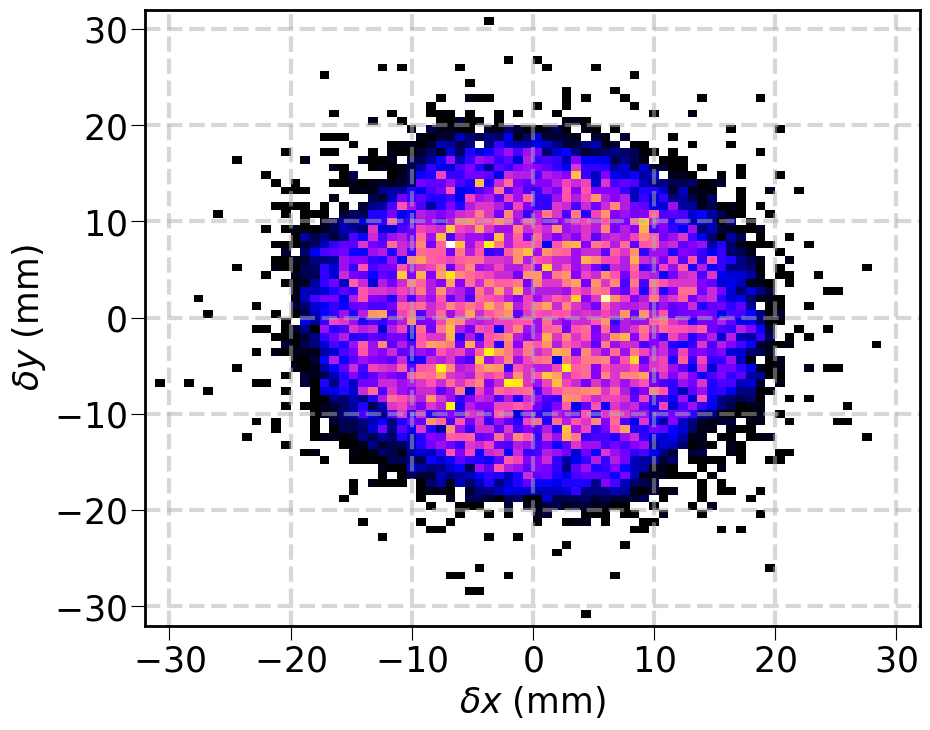

In [11]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

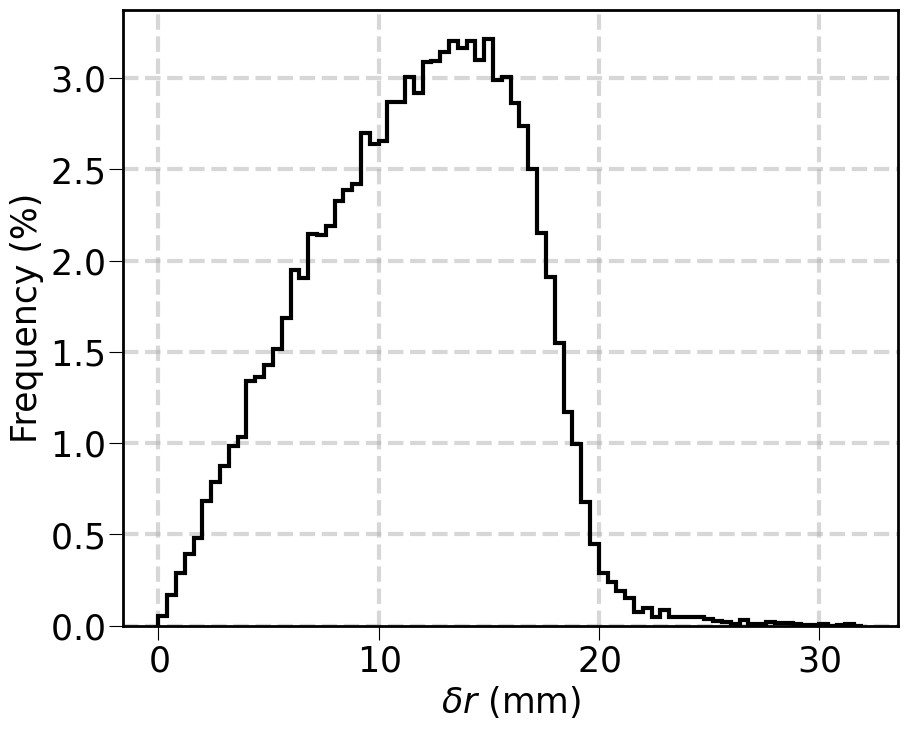

In [12]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

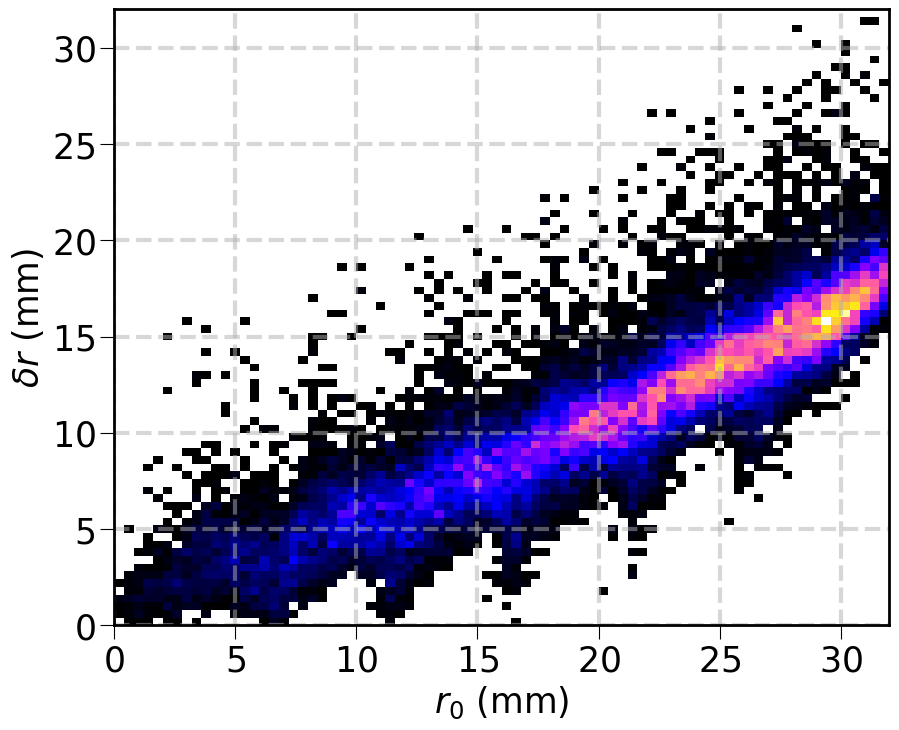

In [13]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

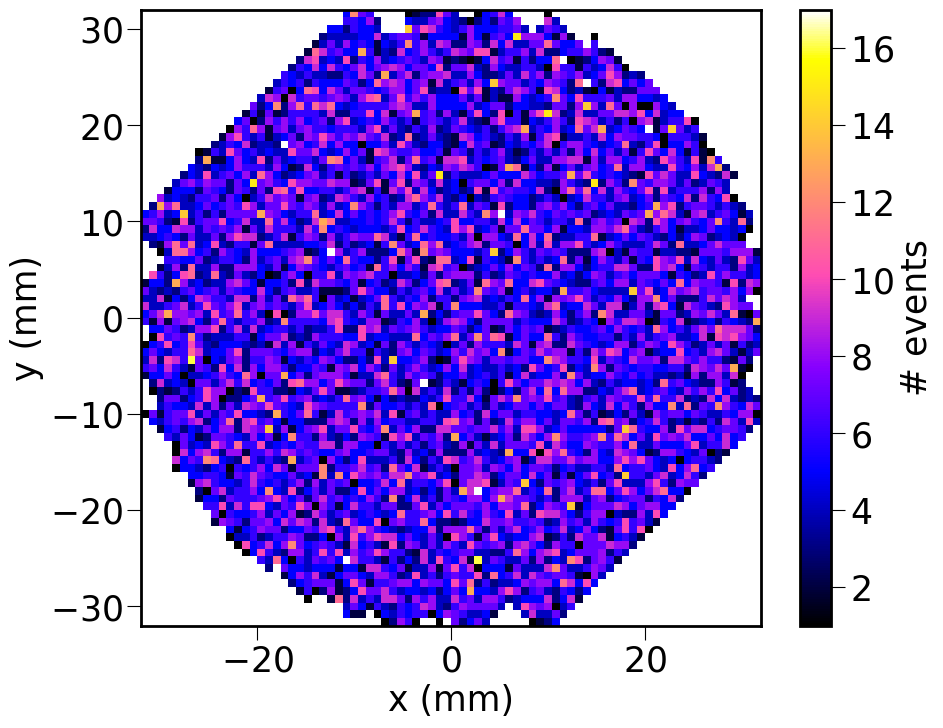

In [14]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

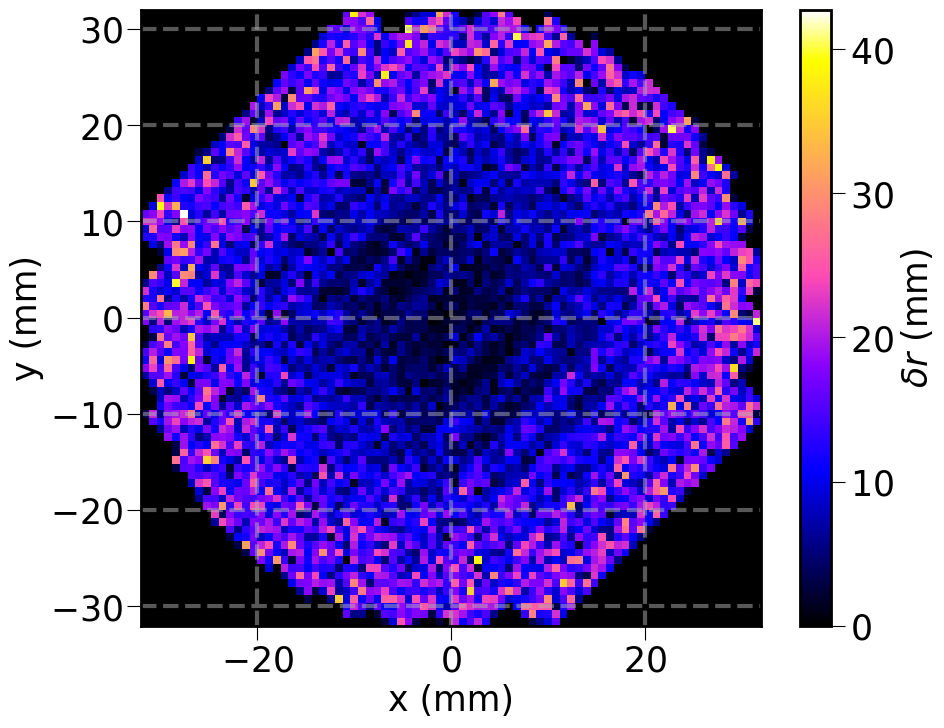

In [15]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

In [17]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [18]:
nfiles    = len(filenames)
train     = pd.concat([imgs_from_file(filename) for filename in filenames[:nfiles//2 ]])
test      = pd.concat([imgs_from_file(filename) for filename in filenames[ nfiles//2:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [19]:
model     = Linear(config.n_sipm_side, config.n_sipm_side)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
epochs = 100
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 100 of 100 | 6.23 s/item | ETA 0.1 min | Ellapsed 10.3 min


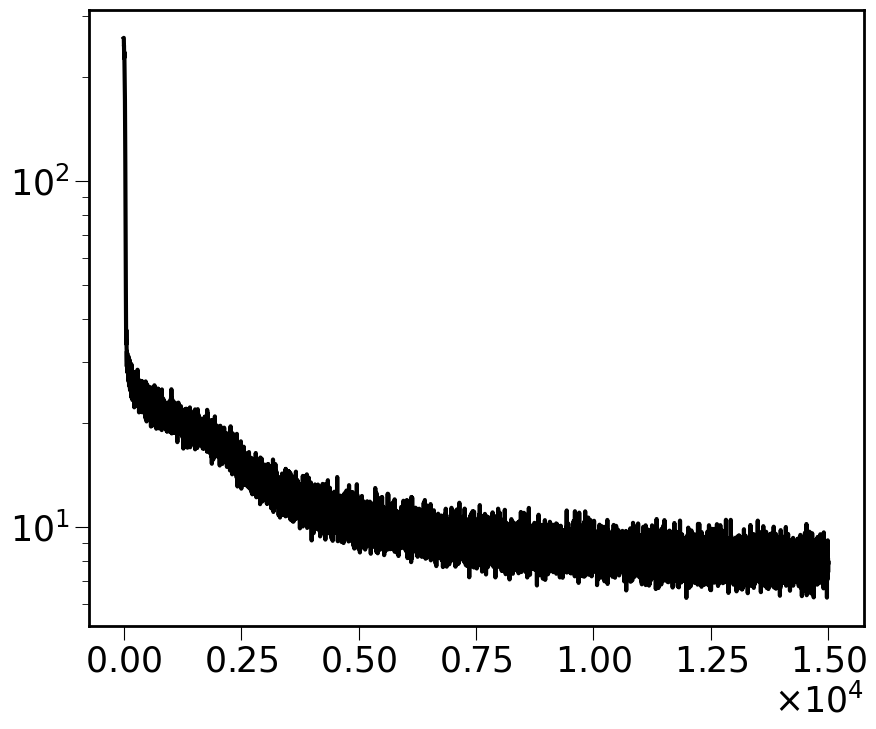

In [21]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [22]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

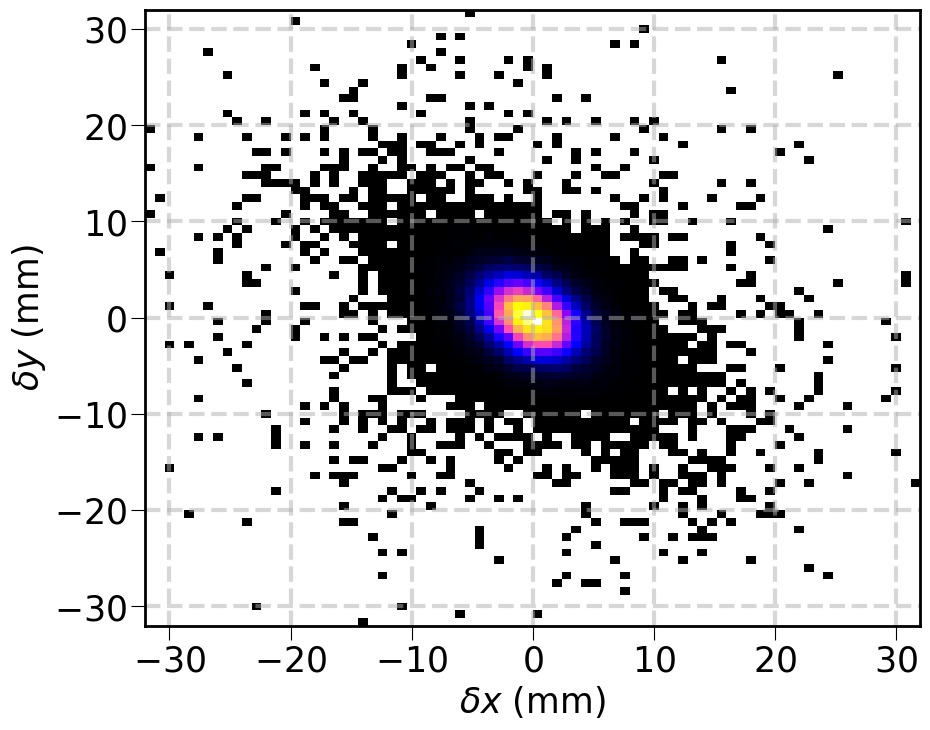

In [23]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

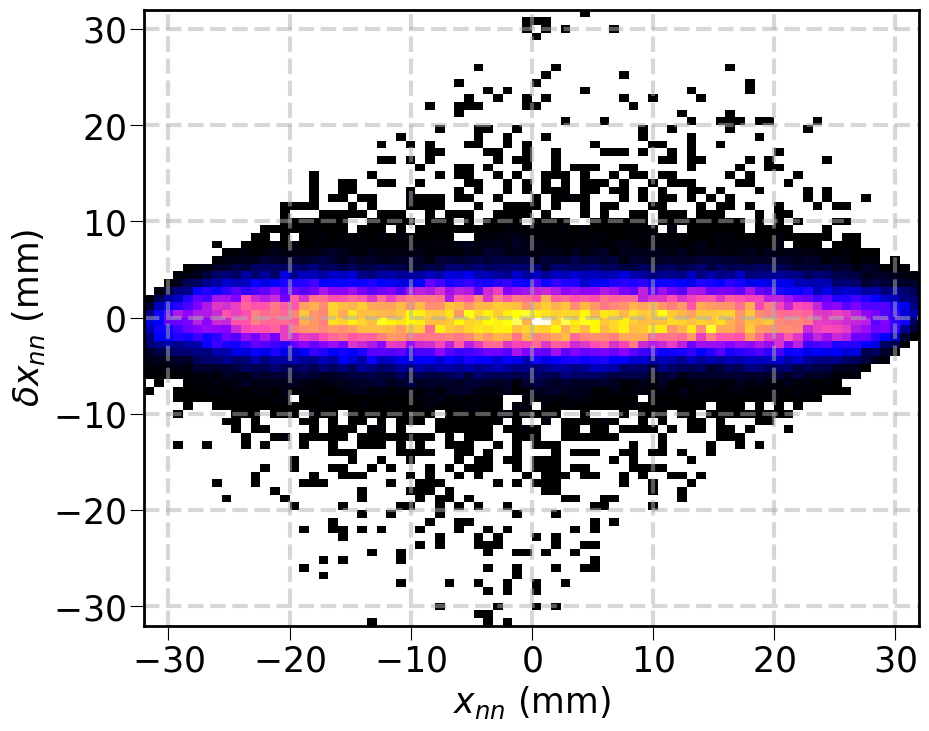

In [24]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_{nn}$ (mm)")
plt.ylabel("$\delta x_{nn}$ (mm)")
plt.grid()

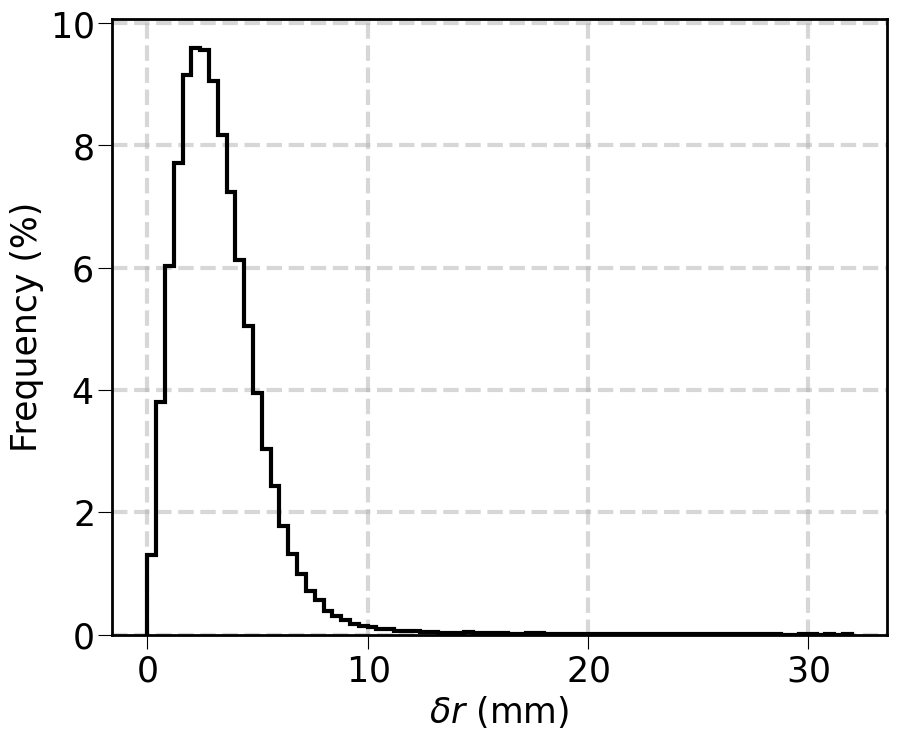

In [25]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

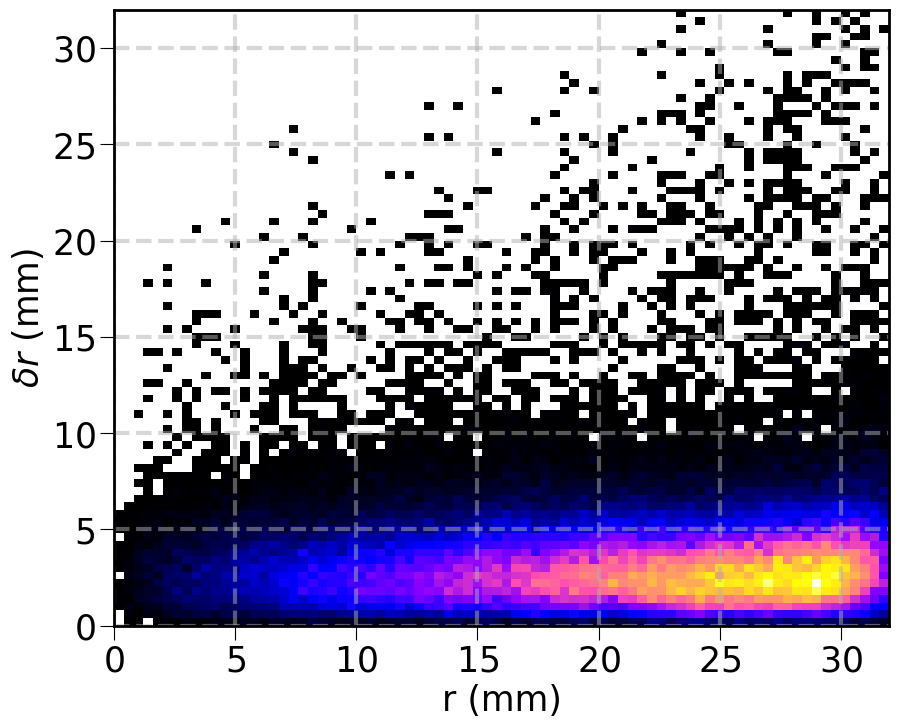

In [26]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

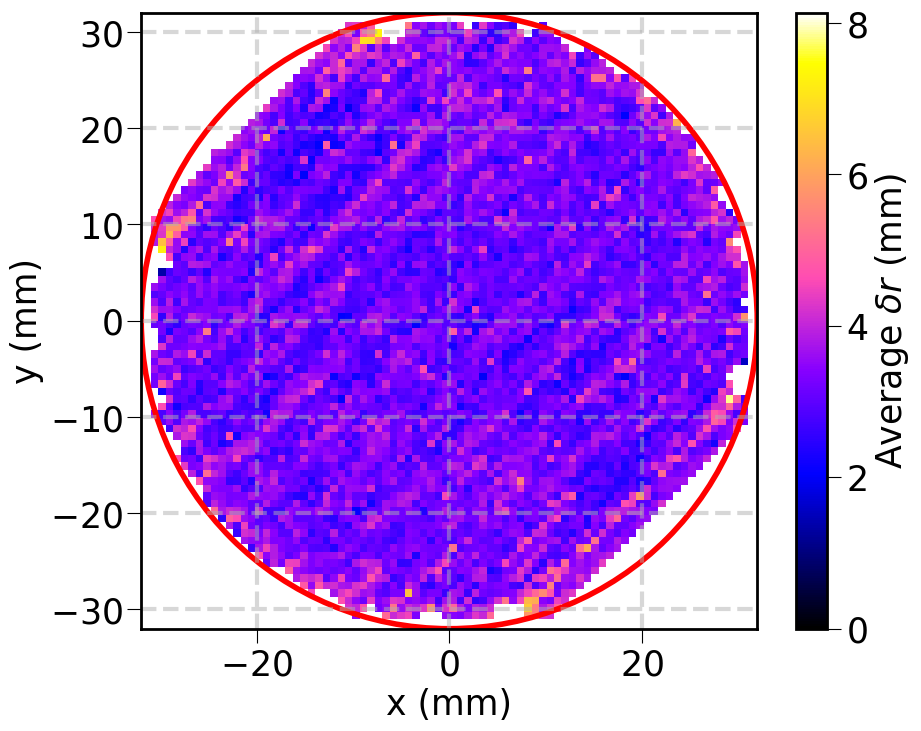

In [27]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=2.5*np.median(errs[errs>0]), extent=extents)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("Average $\delta r$ (mm)")
draw_el(plt.gca(), rmax)
plt.grid()

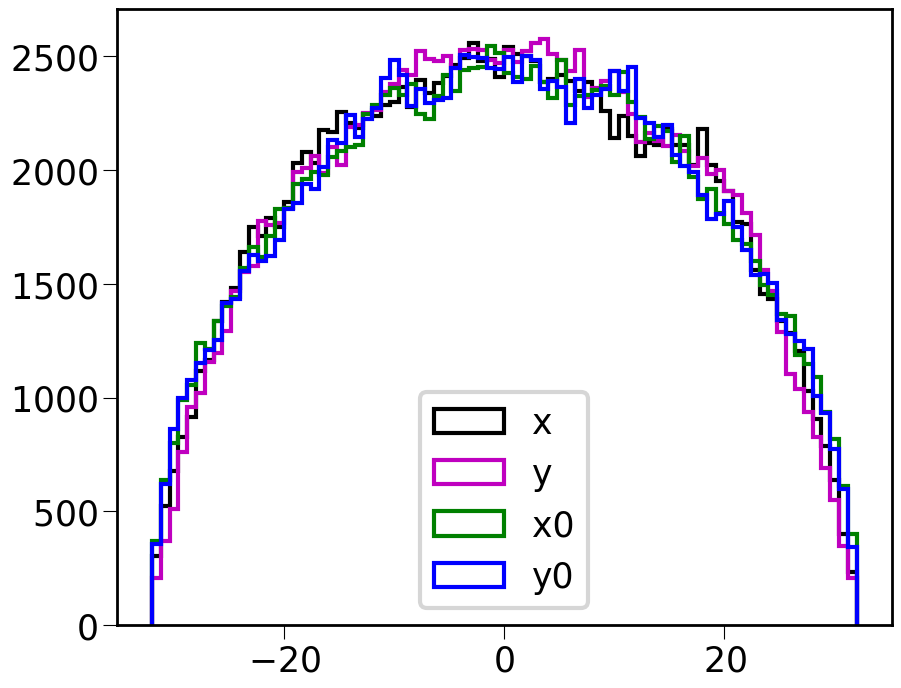

In [28]:
plt.hist(reco_nn.x , xybins, histtype="step", label="x");
plt.hist(reco_nn.y , xybins, histtype="step", label="y");
plt.hist(reco_nn.x0, xybins, histtype="step", label="x0");
plt.hist(reco_nn.y0, xybins, histtype="step", label="y0");
plt.legend()

In [29]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,17.498747,-15.702093,23.510888,16.655586,-15.018417,-0.843161,0.683676,1.085511
1,-2.666499,27.080915,27.211875,-4.320561,28.050286,-1.654062,0.969372,1.917186
2,8.569651,-22.573292,24.145236,8.063617,-20.844393,-0.506035,1.728899,1.801433
3,5.652183,-9.090778,10.704645,7.944635,-10.650839,2.292452,-1.560061,2.772927
4,1.106948,6.003585,6.104783,2.851733,2.907692,1.744785,-3.095893,3.553707
...,...,...,...,...,...,...,...,...
29995,-8.416189,-15.551727,17.682999,-3.676000,-18.858498,4.740189,-3.306771,5.779630
29996,-5.876848,8.908754,10.672546,-4.092320,8.727803,1.784528,-0.180951,1.793679
29997,18.255901,-20.541172,27.481224,16.227069,-22.136800,-2.028832,-1.595628,2.581121


In [30]:
output = filenames[0].parent
output = output.parent / (output.stem + "_reco_summary.h5")
reco_nn.to_hdf(output, key="/data", complib="zlib", complevel=4, mode="w")

In [31]:
import datetime
print(f"Last execution: {datetime.datetime.now()}")

Last execution: 2026-03-03 12:25:45.012014
